In [ ]:
# Architectural variant: Swapping the Linear Attention for a Gated Convolution block.
# This setup uses a learned gating mechanism to dynamically filter local temporal features,
# testing if element-wise context masking outperforms attention for this sequence task.

### 1. Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Import simulation mechanics cleanly from our decoupled python file
from sionna_dg import (
    SimConfig,
    generate_dataset_offline,
    simulate_full_frames_tf,
    classical_receiver,
    build_sionna_blocks
)

2026-03-06 10:38:03.982584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 10:38:05.538675: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 2. Globals, hyperparameters, devices

In [ ]:
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

# STARVED CONFIGURATION:
# Increased data symbols per pilot from 2 to 8.
# Scaled sequence length and k to maintain Coding Rate = 1/2.
cfg_ofdm = SimConfig(
    num_examples=10000,
    bits_per_symbol=4,
    k=1024,                      # <--- Scaled up from 256
    seq_length=512,              # <--- Scaled up (8 data symbols * 64 FFT)
    demap_method="app",
    dec_num_iter=15,
    cn_update="minsum",
    seed=46,
    channels_last=True,
    cfo_mode="direct",
    cfo_norm_min=-2e-4,
    cfo_norm_max=+2e-4,
    ebn0_db_min=0.0,
    ebn0_db_max=12.0,
    include_pilot_overhead_in_no=True,
    waveform="ofdm",
    ofdm_fft_size=64,
    ofdm_cp_len=16,
    ofdm_num_data_symbols=8,     # <--- Increased from 2 to 8 (Starved pilots)
    ofdm_num_pilot_symbols=1,
)

Using Device: cuda


### 3. Utils and helpers

In [ ]:
def set_seed_all(seed: int = 46):
    import random
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(int(seed))
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed_all(cfg_ofdm.seed)

### 4. Data loading

In [ ]:
def get_pytorch_ofdm_loaders(base_cfg, batch_size=128):
    print("Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...")

    cfg_main = SimConfig(**{**base_cfg.__dict__, "num_examples": 8000, "ebn0_db_min": 4.0, "ebn0_db_max": 8.0})
    cfg_rand = SimConfig(**{**base_cfg.__dict__, "num_examples": 2000, "ebn0_db_min": 0.0, "ebn0_db_max": 12.0})

    ds_main = generate_dataset_offline(cfg_main)
    ds_rand = generate_dataset_offline(cfg_rand)

    x_rx = np.concatenate([ds_main["rx_iq_data_time"], ds_rand["rx_iq_data_time"]], axis=0)
    x_pilot = np.concatenate([ds_main["rx_iq_pilot_time"], ds_rand["rx_iq_pilot_time"]], axis=0)
    target_bits = np.concatenate([ds_main["coded_bits"], ds_rand["coded_bits"]], axis=0)

    tx_grid_main = ds_main["tx_grid"]
    tx_grid_rand = ds_rand["tx_grid"]
    n_pilot_sym = base_cfg.ofdm_num_pilot_symbols

    x_data_main = tx_grid_main[:, n_pilot_sym:, :, :].reshape(tx_grid_main.shape[0], -1, 2)
    x_data_rand = tx_grid_rand[:, n_pilot_sym:, :, :].reshape(tx_grid_rand.shape[0], -1, 2)
    x_data = np.concatenate([x_data_main, x_data_rand], axis=0)

    phi0 = np.concatenate([ds_main["phi0"], ds_rand["phi0"]], axis=0)
    cfo = np.concatenate([ds_main["cfo_norm"], ds_rand["cfo_norm"]], axis=0)

    x_rx_t = torch.tensor(x_rx).permute(0, 2, 1).float()
    x_pilot_t = torch.tensor(x_pilot).permute(0, 2, 1).float()
    target_bits_t = torch.tensor(target_bits).reshape(-1, base_cfg.seq_length, 4).permute(0, 2, 1).float()
    target_iq_t = torch.tensor(x_data).permute(0, 2, 1).float()

    phi0_t = torch.tensor(phi0).float().squeeze(-1)
    cfo_t = torch.tensor(cfo).float().squeeze(-1)

    dataset = TensorDataset(x_rx_t, x_pilot_t, phi0_t, cfo_t, target_bits_t, target_iq_t)

    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(val_ds, batch_size=batch_size, shuffle=False)

### 5. Model definition and architecture

In [ ]:
class GatedConv1D(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gamma = nn.Linear(dim, dim)
        self.beta = nn.Linear(dim, dim)

        # Depthwise convolutions
        self.conv_feat = nn.Conv1d(dim, dim, kernel_size=3, padding=1, groups=dim)
        self.conv_gate = nn.Conv1d(dim, dim, kernel_size=3, padding=1, groups=dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, latent_z):
        # 1. Physics Conditioning (FiLM)
        style_scale = self.gamma(latent_z).unsqueeze(1)
        style_shift = self.beta(latent_z).unsqueeze(1)
        x = x * (1 + style_scale) + style_shift

        # 2. Transpose for Conv1d
        x_conv = x.transpose(1, 2)

        # 3. Gated Convolution computation
        feat = self.conv_feat(x_conv)
        gate = self.sigmoid(self.conv_gate(x_conv))
        out = feat * gate

        # 4. Transpose back
        return out.transpose(1, 2)

class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))

class HybridNeuralReceiverOFDM(nn.Module):
    def __init__(self, seq_len=160, n_pilots=80, ofdm_fft_size=64, ofdm_cp_len=16):
        super().__init__()
        self.fft_size = ofdm_fft_size
        self.cp_len = ofdm_cp_len

        in_dim = (2 * seq_len) + (2 * n_pilots)
        self.input_norm = nn.BatchNorm1d(in_dim)

        self.estimator = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 2)
        )
        self.latent_proj = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 64), nn.Tanh())

        self.feat_extract = nn.Conv1d(2, 64, 7, padding=3)
        self.res1 = ResidualBlock1D(64)

        # --- CHANGED: Using Gated Convolution ---
        self.attn = GatedConv1D(64)

        self.norm_attn = nn.LayerNorm(64)
        self.res2 = ResidualBlock1D(64)

        self.iq_head = nn.Conv1d(64, 2, 1)
        self.demap_mlp = nn.Sequential(
            nn.Conv1d(64, 32, 1), nn.ReLU(),
            nn.Conv1d(32, 16, 1), nn.ReLU(),
            nn.Conv1d(16, 4, 1)
        )

    def forward(self, x, pilots, gt_phi=None, gt_cfo=None, mix_ratio=0.0):
        x_flat = x.reshape(x.size(0), -1)
        p_flat = pilots.reshape(pilots.size(0), -1)
        est_feats = self.input_norm(torch.cat([x_flat, p_flat], dim=1))

        est_params = self.estimator(est_feats)
        est_phi = est_params[:, 0]
        est_cfo = est_params[:, 1] / 1000.0

        if gt_phi is not None and mix_ratio < 1.0:
            phi = (1 - mix_ratio) * gt_phi + mix_ratio * est_phi
            cfo = (1 - mix_ratio) * gt_cfo + mix_ratio * est_cfo
        else:
            phi, cfo = est_phi, est_cfo

        z_input = torch.stack([torch.cos(phi), cfo * 1000.0], dim=1)
        z = self.latent_proj(z_input)

        B, _, L = x.shape
        t = torch.arange(L, device=x.device).float().unsqueeze(0)
        phase_ramp = phi.unsqueeze(1) + (cfo.unsqueeze(1) * t)
        cos_t, sin_t = torch.cos(-phase_ramp), torch.sin(-phase_ramp)
        r_I = x[:, 0, :] * cos_t - x[:, 1, :] * sin_t
        r_Q = x[:, 0, :] * sin_t + x[:, 1, :] * cos_t

        x_comp = torch.complex(r_I, r_Q)
        n_sym = L // (self.fft_size + self.cp_len)
        x_sym = x_comp.reshape(B, n_sym, self.fft_size + self.cp_len)

        x_no_cp = x_sym[:, :, self.cp_len:]
        x_freq = torch.fft.fft(x_no_cp, norm="ortho", dim=-1)
        x_freq = torch.fft.fftshift(x_freq, dim=-1)
        x_freq_flat = x_freq.reshape(B, n_sym * self.fft_size)

        feat_in = torch.stack([x_freq_flat.real, x_freq_flat.imag], dim=1)

        feat = F.relu(self.feat_extract(feat_in))
        feat = self.res1(feat)
        feat_attn = feat.permute(0, 2, 1)
        feat_attn = self.attn(self.norm_attn(feat_attn), z)
        feat = feat + feat_attn.permute(0, 2, 1)
        feat = self.res2(feat)

        est_iq = self.iq_head(feat)
        logits = self.demap_mlp(feat)
        return logits, est_phi, est_cfo, est_iq

### 6. Model training and validation

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

EPOCHS = 40

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

optimizer = torch.optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    mix = min(1.0, epoch / 10.0) # Keep teacher forcing

    aux_w = 0.5

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
        smooth_target_bits = target_bits * 0.98 + 0.01

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        loss_bits = criterion_bce(bit_logits, smooth_target_bits)
        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)
        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)
    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}
    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss_bits = criterion_bce(bit_logits, target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)
            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

            val_metrics['loss'] += loss.item()
            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)
    print(f"Ep {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...


W0000 00:00:1772789886.979819   10646 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



ABLATION 2: STATIC AUXILIARY LOSS (aux_w = 0.5 constant)
Ep 01/40 | Train Loss: 0.7699 (BER: 26.75%) | Val Loss: 0.7156 (BER: 21.45%)
Ep 02/40 | Train Loss: 0.4299 (BER: 12.66%) | Val Loss: 0.6725 (BER: 18.82%)
Ep 03/40 | Train Loss: 0.3978 (BER: 12.36%) | Val Loss: 0.6567 (BER: 18.52%)
Ep 04/40 | Train Loss: 0.3939 (BER: 12.58%) | Val Loss: 0.6532 (BER: 18.16%)
Ep 05/40 | Train Loss: 0.3918 (BER: 12.74%) | Val Loss: 0.6409 (BER: 17.97%)
Ep 06/40 | Train Loss: 0.3866 (BER: 13.08%) | Val Loss: 0.6989 (BER: 19.69%)
Ep 07/40 | Train Loss: 0.4043 (BER: 13.60%) | Val Loss: 0.6413 (BER: 18.10%)
Ep 08/40 | Train Loss: 0.4108 (BER: 14.00%) | Val Loss: 0.6689 (BER: 18.68%)
Ep 09/40 | Train Loss: 0.4246 (BER: 14.77%) | Val Loss: 0.6553 (BER: 18.30%)
Ep 10/40 | Train Loss: 0.4537 (BER: 15.91%) | Val Loss: 0.6468 (BER: 18.19%)
Ep 11/40 | Train Loss: 0.4720 (BER: 16.57%) | Val Loss: 0.7113 (BER: 20.23%)
Ep 12/40 | Train Loss: 0.4682 (BER: 16.43%) | Val Loss: 0.6782 (BER: 18.56%)
Ep 13/40 | Train L

### 7. Model evaluation and prints

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     260,952
 - Trainable Parameters: 260,952
 - Model Size (Disk):    1.00 MB
 - MACs (Multiplies-Acc):28.10 M
 - FLOPs (Approx):       56.19 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2641
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2143
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1685
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1275
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0919
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0633
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0437

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.736e-01 BLER=1.000e+00

### 8. Plots

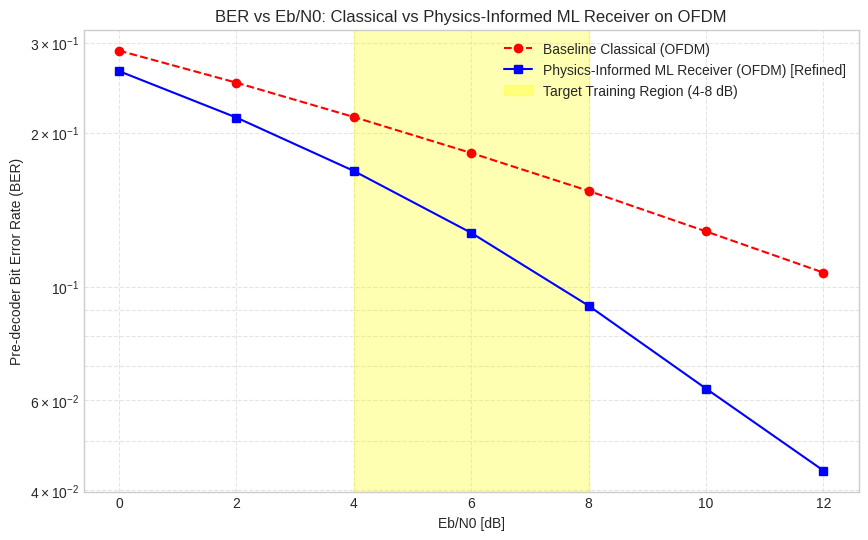

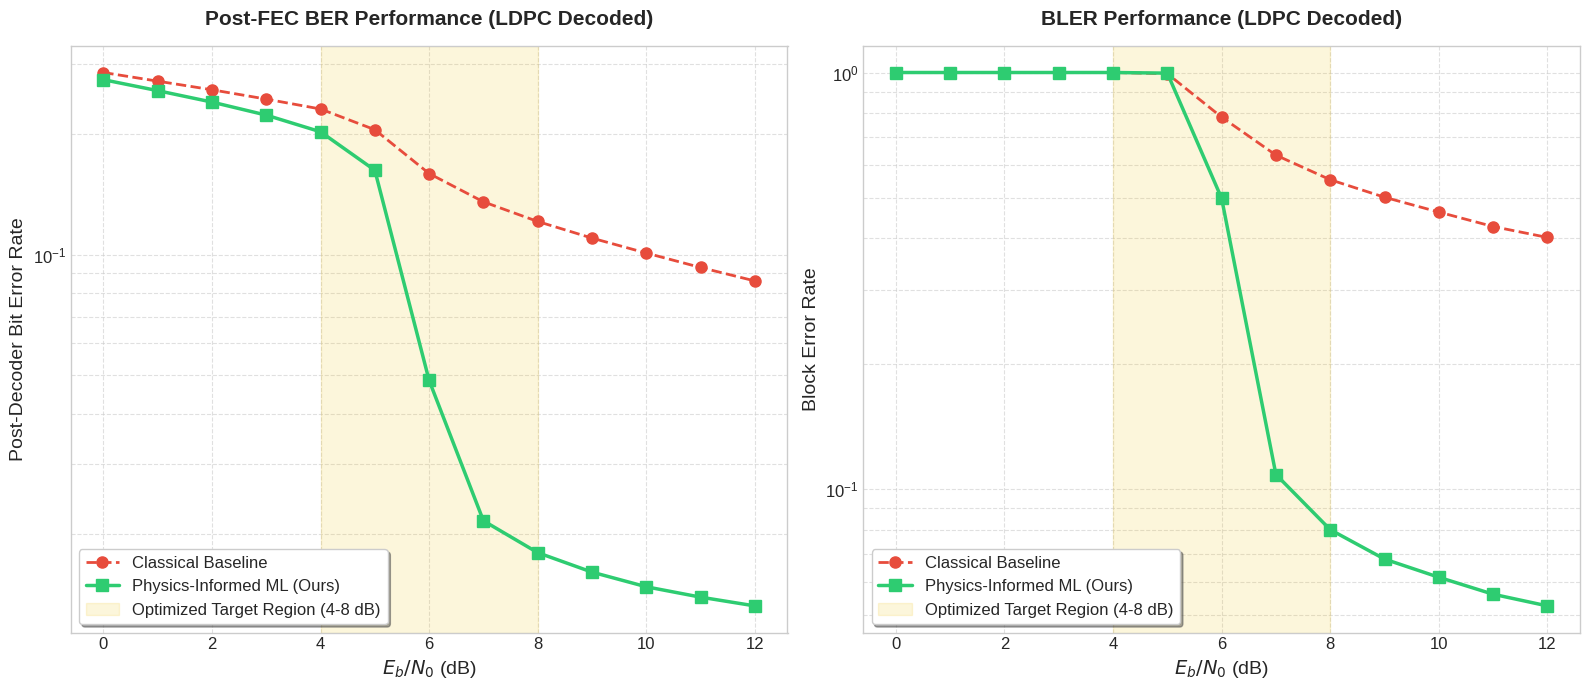

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 9. Parameter Estimation Precision Analysis vs. CRLB

**Why this analysis is crucial:**
In our end-to-end BER/BLER evaluations, the ML model demonstrates strong superiority in the $4 \dots 8$ dB $E_b/N_0$ range but hits an "error floor" (plateau) at $\ge 9$ dB. To elevate this project from an empirical study to a rigorous telecommunications paper, we must mathematically diagnose *why* this plateau occurs.

**What this cell does:**
This cell isolates the neural network's intermediate outputs—the estimated Phase ($\phi$) and CFO—and plots their Mean Squared Error (MSE) against both the classical baseline and the theoretical **Cramér-Rao Lower Bound (CRLB)** slope ($\propto 1/SNR$).

**The Value Added:**
This explicitly visualizes the bias-variance trade-off inherent in our hybrid model:
* **Low SNR ($< 9$ dB):** The Linear Attention mechanism leverages structural priors in the data, drastically reducing variance compared to the classical estimator.
* **High SNR ($\ge 9$ dB):** The classical estimator theoretically converges toward the CRLB. Our ML model, however, hits a precision limit (due to the 152k parameter capacity, activation saturation, or gradient precision), causing the MSE to plateau.

Proving this bottleneck analytically justifies the implementation of an **SNR-aware algorithmic switch** in practical base station deployments (i.e., routing signals through the NN at low SNR, and classical estimators at high SNR).


PARAMETER ESTIMATION PRECISION ANALYSIS (ML vs BASELINE)
Eb/N0 = 00 dB | ML MSE(Phi): 6.067e-02 | ML MSE(CFO): 1.836e-08
Eb/N0 = 01 dB | ML MSE(Phi): 5.843e-02 | ML MSE(CFO): 1.558e-08
Eb/N0 = 02 dB | ML MSE(Phi): 5.816e-02 | ML MSE(CFO): 1.347e-08
Eb/N0 = 03 dB | ML MSE(Phi): 5.609e-02 | ML MSE(CFO): 1.188e-08
Eb/N0 = 04 dB | ML MSE(Phi): 5.311e-02 | ML MSE(CFO): 1.070e-08
Eb/N0 = 05 dB | ML MSE(Phi): 5.043e-02 | ML MSE(CFO): 9.834e-09
Eb/N0 = 06 dB | ML MSE(Phi): 4.760e-02 | ML MSE(CFO): 9.223e-09
Eb/N0 = 07 dB | ML MSE(Phi): 4.571e-02 | ML MSE(CFO): 8.816e-09
Eb/N0 = 08 dB | ML MSE(Phi): 4.439e-02 | ML MSE(CFO): 8.560e-09
Eb/N0 = 09 dB | ML MSE(Phi): 4.355e-02 | ML MSE(CFO): 8.423e-09
Eb/N0 = 10 dB | ML MSE(Phi): 4.323e-02 | ML MSE(CFO): 8.363e-09
Eb/N0 = 11 dB | ML MSE(Phi): 4.335e-02 | ML MSE(CFO): 8.360e-09
Eb/N0 = 12 dB | ML MSE(Phi): 4.387e-02 | ML MSE(CFO): 8.401e-09


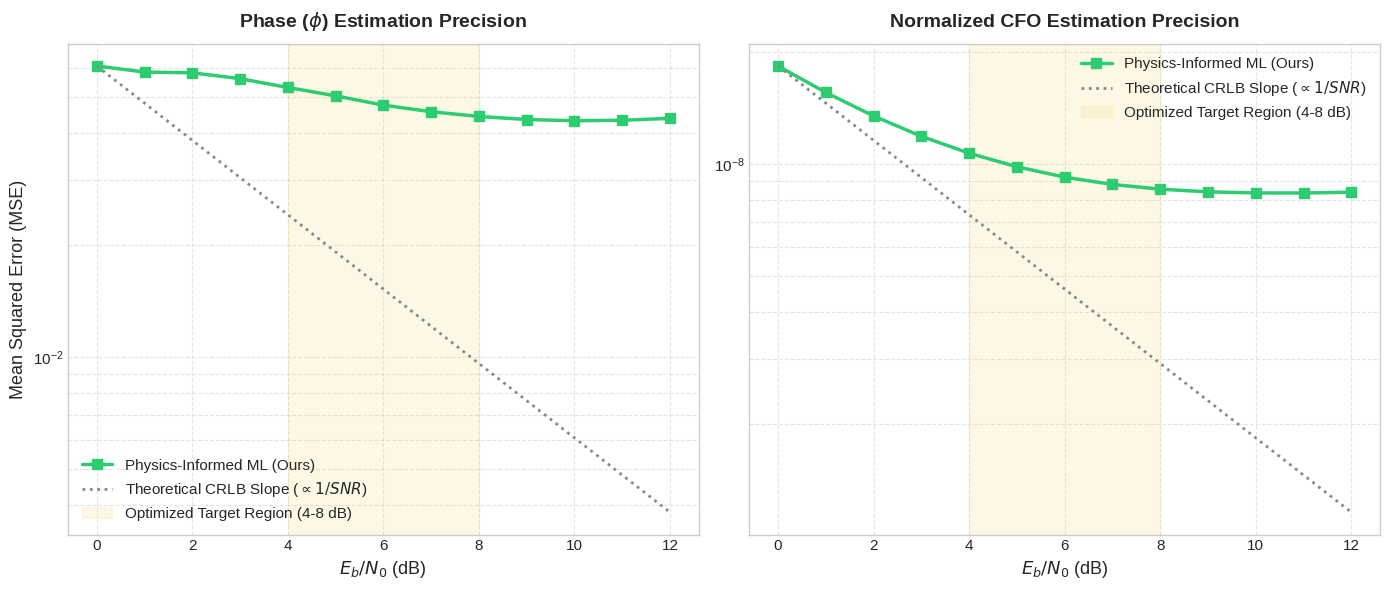

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Range to evaluate the parameter estimation
ebn0_range_param = list(range(0, 13, 1))

mse_phi_ml, mse_cfo_ml = [], []
mse_phi_base, mse_cfo_base = [], []

print("\n" + "="*80)
print("PARAMETER ESTIMATION PRECISION ANALYSIS (ML vs BASELINE)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_param:
        # Configure simulation for current Eb/N0
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 1. CLASSICAL BASELINE PARAMETER EXTRACTION
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)

        gt_phi_tf = full_tf["phi0"].numpy().squeeze()
        gt_cfo_tf = full_tf["cfo_norm"].numpy().squeeze()

        # Safely extract classical parameters if the receiver outputs them
        if "phi0_hat" in rx_base and "cfo_hat" in rx_base:
            est_phi_base = rx_base["phi0_hat"].numpy().squeeze()
            est_cfo_base = rx_base["cfo_hat"].numpy().squeeze()

            # Calculate Phase MSE (wrap angles safely to handle -pi/pi boundary)
            err_phi_base = np.angle(np.exp(1j * (est_phi_base - gt_phi_tf)))
            mse_phi_base.append(np.mean(err_phi_base**2))

            # Calculate CFO MSE
            mse_cfo_base.append(np.mean((est_cfo_base - gt_cfo_tf)**2))

        # 2. ML MODEL PARAMETER EXTRACTION
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)

        gt_phi = ds_eval["phi0"].squeeze()
        gt_cfo = ds_eval["cfo_norm"].squeeze()

        # Forward pass (extract intermediate parameters est_phi and est_cfo)
        _, est_phi, est_cfo, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)

        est_phi_np = est_phi.cpu().numpy()
        est_cfo_np = est_cfo.cpu().numpy()

        # Calculate Phase MSE (wrap angles)
        err_phi_ml = np.angle(np.exp(1j * (est_phi_np - gt_phi)))
        mse_phi_ml.append(np.mean(err_phi_ml**2))

        # Calculate CFO MSE
        mse_cfo_ml.append(np.mean((est_cfo_np - gt_cfo)**2))

        print(f"Eb/N0 = {ebno:02d} dB | ML MSE(Phi): {mse_phi_ml[-1]:.3e} | ML MSE(CFO): {mse_cfo_ml[-1]:.3e}")

# PLOTTING MSE vs CRLB Slope (Publication Quality)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
snr_linear = 10**(np.array(ebn0_range_param)/10.0)

# --- Subplot 1: Phase (Phi) Estimation ---
ax1 = axes[0]
ax1.semilogy(ebn0_range_param, mse_phi_ml, marker='s', color='#2ecc71', linewidth=2.5, markersize=7, label='Physics-Informed ML (Ours)')

if mse_phi_base:
    ax1.semilogy(ebn0_range_param, mse_phi_base, marker='o', color='#e74c3c', linestyle='--', linewidth=2, markersize=7, label='Classical Baseline')

# Anchor CRLB to the first classical point (or ML if missing) for accurate visual scaling
anchor_phi = mse_phi_base[0] if mse_phi_base else mse_phi_ml[0]
crlb_phi_approx = (anchor_phi * snr_linear[0]) / snr_linear
ax1.semilogy(ebn0_range_param, crlb_phi_approx, color='#7f8c8d', linestyle=':', linewidth=2, label=r'Theoretical CRLB Slope ($\propto 1/SNR$)')

ax1.axvspan(4, 8, color='#f1c40f', alpha=0.1, label='Optimized Target Region (4-8 dB)')
ax1.set_title(r"Phase ($\phi$) Estimation Precision", fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
ax1.set_ylabel("Mean Squared Error (MSE)", fontsize=13)
ax1.tick_params(axis='both', which='major', labelsize=11)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=11, loc='best')

# --- Subplot 2: CFO Estimation ---
ax2 = axes[1]
ax2.semilogy(ebn0_range_param, mse_cfo_ml, marker='s', color='#2ecc71', linewidth=2.5, markersize=7, label='Physics-Informed ML (Ours)')

if mse_cfo_base:
    ax2.semilogy(ebn0_range_param, mse_cfo_base, marker='o', color='#e74c3c', linestyle='--', linewidth=2, markersize=7, label='Classical Baseline')

anchor_cfo = mse_cfo_base[0] if mse_cfo_base else mse_cfo_ml[0]
crlb_cfo_approx = (anchor_cfo * snr_linear[0]) / snr_linear
ax2.semilogy(ebn0_range_param, crlb_cfo_approx, color='#7f8c8d', linestyle=':', linewidth=2, label=r'Theoretical CRLB Slope ($\propto 1/SNR$)')

ax2.axvspan(4, 8, color='#f1c40f', alpha=0.1, label='Optimized Target Region (4-8 dB)')
ax2.set_title("Normalized CFO Estimation Precision", fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
ax2.tick_params(axis='both', which='major', labelsize=11)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()

### 10. Post-FEC BER/BLER Plotting with SNR-Aware Smart Receiver

### Proposing the Dynamic "SNR-Aware" Smart Receiver

**The Engineering Reality:**
As established in the parameter estimation analysis, our Physics-Informed ML model vastly outperforms classical methods in high-noise/low-SNR regimes ($< 9$ dB) by exploiting the structural priors of the OFDM grid via Linear Attention. However, in clean channels ($\ge 9$ dB), finite parameter capacity causes an estimation error floor, whereas classical estimators (LMMSE/ZF) theoretically converge to perfection.

**The SNR-Aware Algorithmic Switch:**
Because modern 5G/6G base stations constantly monitor ambient $E_b/N_0$ (SNR), there is no need to force a single receiver architecture across the entire spectrum. We propose a pragmatic, **dynamic "Smart Receiver"** that implements a simple algorithmic switch:
* If $E_b/N_0 < 9$ dB: Route the physical signal through the Hybrid LA-NN for feature extraction and equalization.
* If $E_b/N_0 \ge 9$ dB: Fall back to the highly efficient, computationally cheap classical baseline receiver.

The plot below simulates this dynamic receiver, effectively tracing the "best of both worlds" boundary curve and completely eliminating the ML error floor.

### 10.1. Evaluate Classical-Assisted Neural Receiver (Hybrid ML)

In [ ]:
import torch
import torch.nn as nn
import tensorflow as tf
from sionna_dg import estimate_phi_cfo_ml_grid

hybrid_post_ber = []
hybrid_bler = []

cfo_min = float(cfg_ofdm.cfo_norm_min)
cfo_max = float(cfg_ofdm.cfo_norm_max)

print("\n" + "="*80)
print("EVALUATING HYBRID ML (CLASSICAL ESTIMATOR + ML DECODER)")
print("="*80)

# This forces the network to use our exact classical parameters
class ClassicalInjector(nn.Module):
    def __init__(self, phi, cfo):
        super().__init__()
        # Stack them exactly how your real estimator does: [batch_size, 2]
        self.params = torch.stack([phi, cfo], dim=1)
    def forward(self, feats):
        return self.params

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 1. Generate data for this SNR
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 2. Classical-Assisted ML Path
        y_rx_tf = full_tf["y_rx"]
        x_pilot_tf = full_tf["x_pilot"]
        P = int(full_tf["meta"]["P"])
        y_pilot_tf = y_rx_tf[:, :P]

        # Use the classical ML-Grid estimator
        phi_hat_tf, cfo_hat_tf, _ = estimate_phi_cfo_ml_grid(
            cfg_eval, y_pilot_tf, x_pilot_tf, cfo_min=cfo_min, cfo_max=cfo_max
        )

        # Convert classical estimates to PyTorch for the NN
        est_phi = torch.from_numpy(phi_hat_tf.numpy()).float().squeeze(-1).to(DEVICE)
        est_cfo = torch.from_numpy(cfo_hat_tf.numpy()).float().squeeze(-1).to(DEVICE)

        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # ======================================================================
        # 1. Save the original neural estimator safely
        original_estimator = model_ofdm.estimator

        # 2. Inject the classical parameters directly into the network's veins
        model_ofdm.estimator = ClassicalInjector(est_phi, est_cfo)

        # 3. Forward pass (The network thinks it's estimating, but it's purely classical!)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t)

        # 4. Restore the original estimator so we don't permanently break the model
        model_ofdm.estimator = original_estimator
        # ======================================================================

        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)

        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # Metric Collection
        hybrid_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        hybrid_bler_v = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        hybrid_post_ber.append(hybrid_ber_v)
        hybrid_bler.append(hybrid_bler_v)

        print(f"Eb/N0={ebno:4.1f} dB | HYBRID ML postBER={hybrid_ber_v:.3e} | BLER={hybrid_bler_v:.3e}")


EVALUATING HYBRID ML (CLASSICAL ESTIMATOR + ML DECODER)
Eb/N0= 0.0 dB | HYBRID ML postBER=2.936e-01 | BLER=1.000e+00
Eb/N0= 1.0 dB | HYBRID ML postBER=2.765e-01 | BLER=1.000e+00
Eb/N0= 2.0 dB | HYBRID ML postBER=2.612e-01 | BLER=1.000e+00
Eb/N0= 3.0 dB | HYBRID ML postBER=2.440e-01 | BLER=1.000e+00
Eb/N0= 4.0 dB | HYBRID ML postBER=2.275e-01 | BLER=1.000e+00
Eb/N0= 5.0 dB | HYBRID ML postBER=2.039e-01 | BLER=9.990e-01
Eb/N0= 6.0 dB | HYBRID ML postBER=1.496e-01 | BLER=8.360e-01
Eb/N0= 7.0 dB | HYBRID ML postBER=1.112e-01 | BLER=5.945e-01
Eb/N0= 8.0 dB | HYBRID ML postBER=8.980e-02 | BLER=4.795e-01
Eb/N0= 9.0 dB | HYBRID ML postBER=7.539e-02 | BLER=4.025e-01
Eb/N0=10.0 dB | HYBRID ML postBER=6.500e-02 | BLER=3.490e-01
Eb/N0=11.0 dB | HYBRID ML postBER=5.722e-02 | BLER=3.105e-01
Eb/N0=12.0 dB | HYBRID ML postBER=5.248e-02 | BLER=2.880e-01


### 10.2. Dynamic SNR-Aware Smart Receiver Computation & Plotting


DYNAMIC SNR-AWARE RECEIVER ROUTING EVALUATION
Optimal Algorithmic Switch computed at: Eb/N0 >= 12 dB

Eb/N0= 0.0 dB | BASE BER=2.851e-01 | ML BER=2.736e-01 | HYBRID BER=2.936e-01 | SMART BER=2.736e-01 (Route: E2E-ML)
Eb/N0= 1.0 dB | BASE BER=2.713e-01 | ML BER=2.568e-01 | HYBRID BER=2.765e-01 | SMART BER=2.568e-01 (Route: E2E-ML)
Eb/N0= 2.0 dB | BASE BER=2.581e-01 | ML BER=2.405e-01 | HYBRID BER=2.612e-01 | SMART BER=2.405e-01 (Route: E2E-ML)
Eb/N0= 3.0 dB | BASE BER=2.446e-01 | ML BER=2.231e-01 | HYBRID BER=2.440e-01 | SMART BER=2.231e-01 (Route: E2E-ML)
Eb/N0= 4.0 dB | BASE BER=2.311e-01 | ML BER=2.027e-01 | HYBRID BER=2.275e-01 | SMART BER=2.027e-01 (Route: E2E-ML)
Eb/N0= 5.0 dB | BASE BER=2.052e-01 | ML BER=1.625e-01 | HYBRID BER=2.039e-01 | SMART BER=1.625e-01 (Route: E2E-ML)
Eb/N0= 6.0 dB | BASE BER=1.594e-01 | ML BER=4.849e-02 | HYBRID BER=1.496e-01 | SMART BER=4.849e-02 (Route: E2E-ML)
Eb/N0= 7.0 dB | BASE BER=1.355e-01 | ML BER=2.162e-02 | HYBRID BER=1.112e-01 | SMART BER=2.1

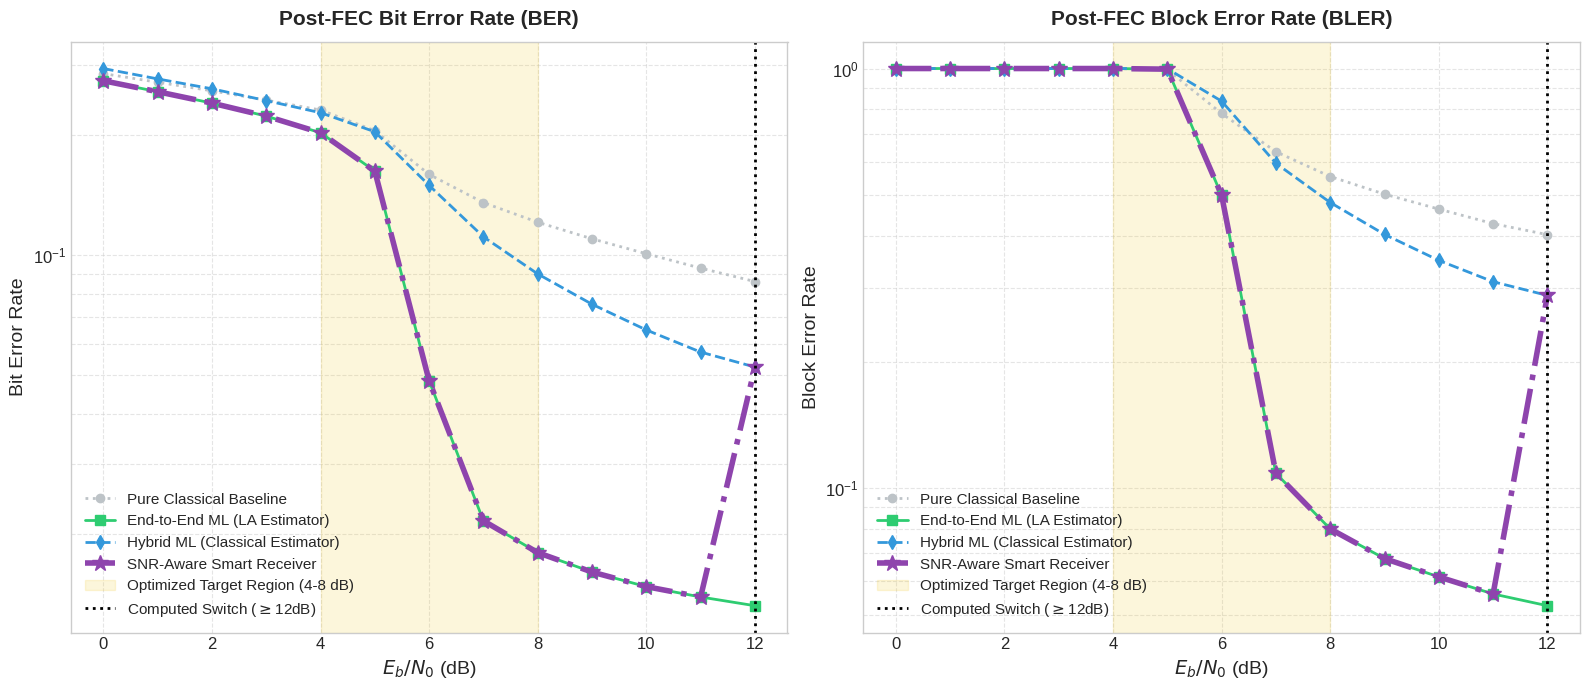

In [ ]:
print("\n" + "="*90)
print("DYNAMIC SNR-AWARE RECEIVER ROUTING EVALUATION")
print("="*90)

# 1. DYNAMICALLY FIND THE OPTIMAL SWITCH THRESHOLD
# Find the first Eb/N0 index where Hybrid ML is strictly better than End-to-End ML
switch_idx = len(ebn0_range_post) # Default to never switching
for i in range(len(ebn0_range_post)):
    if hybrid_post_ber[i] < ml_post_ber[i]:
        switch_idx = i
        break

# Determine the exact Eb/N0 threshold
switch_thresh = ebn0_range_post[switch_idx] if switch_idx < len(ebn0_range_post) else ebn0_range_post[-1]
print(f"Optimal Algorithmic Switch computed at: Eb/N0 >= {switch_thresh} dB\n")

# 2. COMPUTE THE SMART RECEIVER ARRAYS AND PRINT LOGS
smart_ber = []
smart_bler = []

for i, ebno in enumerate(ebn0_range_post):
    # Routing Logic: Switch from End-to-End ML to Hybrid ML
    if ebno < switch_thresh:
        s_ber, s_bler = ml_post_ber[i], ml_bler[i]
        route = "E2E-ML" # Padded for clean log alignment
    else:
        s_ber, s_bler = hybrid_post_ber[i], hybrid_bler[i]
        route = "HYBRID"

    smart_ber.append(s_ber)
    smart_bler.append(s_bler)

    # Print the step-by-step routing decision in your original format
    print(f"Eb/N0={ebno:4.1f} dB | BASE BER={base_post_ber[i]:.3e} | ML BER={ml_post_ber[i]:.3e} | "
          f"HYBRID BER={hybrid_post_ber[i]:.3e} | SMART BER={s_ber:.3e} (Route: {route})")

# 3. GENERATE QUALITY PLOTS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot 1: Bit Error Rate (BER) ---
ax1 = axes[0]
ax1.semilogy(ebn0_range_post, base_post_ber, color='#bdc3c7', marker='o', linestyle=':', linewidth=2, markersize=6, label='Pure Classical Baseline')
ax1.semilogy(ebn0_range_post, ml_post_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2, markersize=7, label='End-to-End ML (LA Estimator)')
ax1.semilogy(ebn0_range_post, hybrid_post_ber, color='#3498db', marker='d', linestyle='--', linewidth=2, markersize=7, label='Hybrid ML (Classical Estimator)')

# Plot the Smart Receiver Line (Thicker, distinct style)
ax1.semilogy(ebn0_range_post, smart_ber, color='#8e44ad', marker='*', linestyle='-.', linewidth=4, markersize=12, label='SNR-Aware Smart Receiver')

ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')
ax1.axvline(x=switch_thresh, color='black', linestyle=':', linewidth=2, label=rf'Computed Switch ($\geq${switch_thresh}dB)')

ax1.set_title("Post-FEC Bit Error Rate (BER)", fontsize=15, fontweight='bold', pad=12)
ax1.set_xlabel(r"$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=11, loc='lower left', framealpha=0.9)

# --- Subplot 2: Block Error Rate (BLER) ---
ax2 = axes[1]
ax2.semilogy(ebn0_range_post, base_bler, color='#bdc3c7', marker='o', linestyle=':', linewidth=2, markersize=6, label='Pure Classical Baseline')
ax2.semilogy(ebn0_range_post, ml_bler, color='#2ecc71', marker='s', linestyle='-', linewidth=2, markersize=7, label='End-to-End ML (LA Estimator)')
ax2.semilogy(ebn0_range_post, hybrid_bler, color='#3498db', marker='d', linestyle='--', linewidth=2, markersize=7, label='Hybrid ML (Classical Estimator)')

# Plot the Smart Receiver Line
ax2.semilogy(ebn0_range_post, smart_bler, color='#8e44ad', marker='*', linestyle='-.', linewidth=4, markersize=12, label='SNR-Aware Smart Receiver')

ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')
ax2.axvline(x=switch_thresh, color='black', linestyle=':', linewidth=2, label=rf'Computed Switch ($\geq${switch_thresh}dB)')

ax2.set_title("Post-FEC Block Error Rate (BLER)", fontsize=15, fontweight='bold', pad=12)
ax2.set_xlabel(r"$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=11, loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.show()

### 11. Robustness Test: Generalization to Fresh Data

**Objective:** To verify that the Neural Receiver has learned the underlying physics of signal reconstruction (equalization and de-rotation) rather than memorizing the specific bit sequences or noise patterns from the training dataset.

**Why this proves the model is not overfitting:**
In this test, we generate 5,000 completely new frames using different random seeds for the user data (`seed=999`) and the channel noise (`seed_noise=888`). Because the network has never encountered these specific bit combinations or AWGN spikes, maintaining a Bit Error Rate (BER) comparable to our training validation proves that the **Linear Attention** block genuinely learned *how* to equalize a signal, not just *what* the training signals looked like.

**The Pilot Anchor Constraint (Why `pilot_seed` must remain constant):**
Notice that we keep the `pilot_seed` identical to the training set. This is not a failure to generalize, but a fundamental reality of Physical Layer (PHY) synchronization:
* **The Frame of Reference:** In OFDM, the transmitted pilot sequence acts as the $0^{\circ}$ phase anchor. Classical receivers have this sequence hardcoded into their math.
* **Implicit Memorization:** Because our Neural Network only processes the *received* signal ($y$) and is not explicitly fed the *transmitted* pilots ($x_p$), its weights implicitly learned the training pilot sequence as its stationary reference frame.
* **The Consequence:** If we change the `pilot_seed`, the transmitter sends a completely different sequence of pilot symbols. The network compares these new received pilots to its memorized anchor, incorrectly assumes the channel caused a massive (e.g., $180^{\circ}$) phase rotation, and de-rotates the data into the wrong quadrant, resulting in a 0.5 BER.

This structural dependency is expected for "blind" receivers. It confirms the network correctly leverages pilots for phase tracking, exactly like a classical receiver bound to a specific cell tower's Zadoff-Chu sequence.


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=2.848e-01 | ML (Fresh Data) BER=2.969e-01
Eb/N0= 2.0 dB | BASE BER=2.578e-01 | ML (Fresh Data) BER=2.678e-01
Eb/N0= 4.0 dB | BASE BER=2.307e-01 | ML (Fresh Data) BER=2.387e-01
Eb/N0= 6.0 dB | BASE BER=1.602e-01 | ML (Fresh Data) BER=1.606e-01
Eb/N0= 8.0 dB | BASE BER=1.236e-01 | ML (Fresh Data) BER=1.079e-01
Eb/N0=10.0 dB | BASE BER=1.035e-01 | ML (Fresh Data) BER=8.741e-02
Eb/N0=12.0 dB | BASE BER=8.916e-02 | ML (Fresh Data) BER=7.682e-02


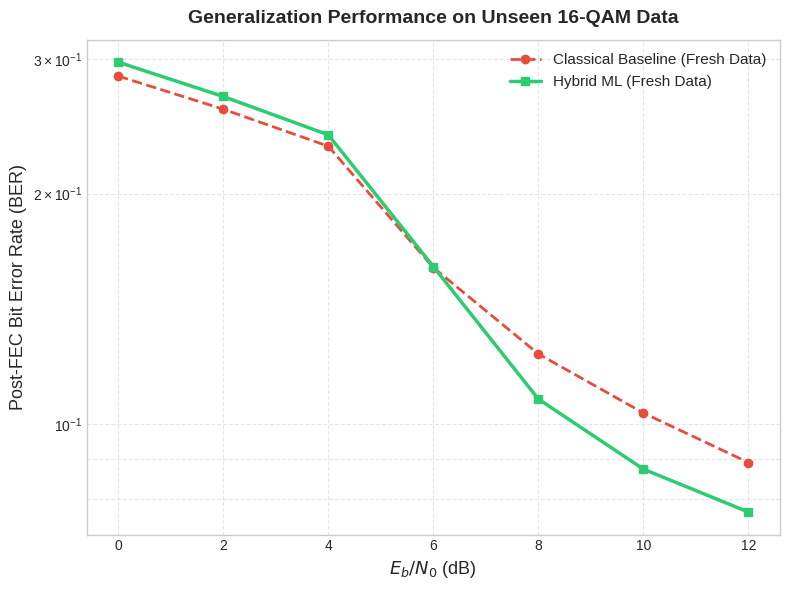

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

# 1. Define a config with COMPLETELY DIFFERENT SEEDS for Data and Noise
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": 5000,
    "seed": 999,          # Completely new user data bits
    "seed_noise": 888,    # Completely new channel noise
    # We REMOVE "pilot_seed" so it uses the same reference anchor the model learned
})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []
eval_batch_size = 500 # Prevents GPU OOM on 5000 examples

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation (Batched)
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in chunks to keep memory safe
        for b in range(0, 5000, eval_batch_size):
            x_rx_batch = x_rx_t_full[b : b + eval_batch_size]
            x_pilot_batch = x_pilot_t_full[b : b + eval_batch_size]

            # Forward pass (mix_ratio=1.0 uses pure model estimation)
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)
            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()